# 1

In [1]:
import numpy as np
import pandas as pd

from fredapi import Fred
from dstapi import DstApi

In [2]:
fred = Fred(api_key="d31571eb7041dd22acc07bd947c0c72e")

#### 1.1

In [ ]:
#1.1.1
from pathlib import Path
import pandas as pd

from states import STATES

#after using API key, saved locally as csv file to avoid repeated downloads
data_dir = Path("fred_data")
rgsp_file = data_dir / "rgsp.csv"
pop_file = data_dir / "pop.csv"

if rgsp_file.exists() and pop_file.exists():
    print("Loading FRED data from local files.")
    rgsp = pd.read_csv(rgsp_file, index_col="year")
    pop = pd.read_csv(pop_file, index_col="year")
else:
    print("Downloading data from FRED.")

    rgsp_data = {}
    pop_data = {}

    for state in STATES:
        rgsp_data[state] = fred.get_series(f"{state}RGSP")
        pop_data[state] = fred.get_series(f"{state}POP")


    rgsp.index = rgsp.index.year
    pop.index = pop.index.year

    rgsp.index.name = "year"
    pop.index.name = "year"

    data_dir.mkdir(exist_ok=True)
    rgsp.to_csv(rgsp_file)
    pop.to_csv(pop_file)

    print("Data saved locally.")

Loading FRED data from local files.


In [4]:
# 1.1.1

# from states import STATES

# rgsp_data = {}
# pop_data = {}
# for s in STATES:
   #  rgsp_data[s] = fred.get_series(f"{s}RGSP")
   #  pop_data[s] =fred.get_series(f"{s}POP")

In [5]:
display(fred.get_series_info("ALRGSP")[["title","frequency","units"]])
display(fred.get_series_info("ALPOP")[["title","frequency","units"]])

title        Real Gross Domestic Product: All Industry Tota...
frequency                                               Annual
units                         Millions of Chained 2017 Dollars
dtype: str

title        Resident Population in Alabama
frequency                            Annual
units                  Thousands of Persons
dtype: str

In [6]:


display(rgsp.head(3))
display(rgsp.tail(3))

display(pop.head(3))
display(pop.tail(3))

,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1997,154700.0,41071.0,180293.9,87180.3,1441226.4,189445.6,205965.2,51267.0,603988.6,351183.9,...,27116.2,226832.8,860046.9,86283.5,21372.2,319992.6,281522.2,60364.6,222978.5,24257.7
1998,160396.4,40263.7,197492.1,89905.3,1538612.3,206449.1,212255.0,56487.0,634032.3,377705.9,...,28772.1,240963.4,920059.6,91312.7,22266.5,338931.5,299817.0,61725.7,232087.1,24804.7
1999,166531.8,39783.1,214293.9,94756.9,1655438.5,221040.8,218860.0,60866.2,664152.0,404465.2,...,30038.3,248457.5,957247.2,95206.8,23561.7,356391.8,322721.6,63691.7,242026.0,25866.8


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
2023,248313.7,54183.8,427644.0,141968.0,3204016.4,440225.2,283228.5,82090.9,1309392.2,679447.2,...,57253.0,428276.1,2137536.7,226322.1,35499.4,599261.0,670977.8,80364.9,347108.2,39843.2
2024,255629.4,55945.7,446968.2,147389.9,3306928.6,448838.5,286160.1,85350.5,1352275.1,697450.9,...,57718.0,440200.2,2221943.3,234300.6,36398.9,613708.7,702232.3,82716.5,354382.1,39780.7
2025,260648.0,57488.0,455745.2,150640.3,3388904.8,458147.1,293002.8,87281.1,1393837.1,710412.3,...,58515.2,449356.6,2277203.3,240786.9,36908.2,623948.9,717520.9,83170.7,359603.1,39990.5


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1900,1830.0,NaN,124.0,1314.0,1490.0,543.0,910.0,185.0,530.0,2220.0,...,403.0,2023.0,3055.0,277.0,344.0,1858.0,523.0,959.0,2072.0,93.0
1901,1907.0,NaN,131.0,1341.0,1550.0,581.0,931.0,187.0,544.0,2263.0,...,418.0,2041.0,3132.0,284.0,347.0,1887.0,583.0,972.0,2109.0,100.0
1902,1935.0,NaN,138.0,1360.0,1623.0,621.0,952.0,188.0,565.0,2305.0,...,431.0,2060.0,3210.0,292.0,349.0,1894.0,651.0,1000.0,2141.0,105.0


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
2023,5117.850,734.654,7452.073,3069.856,39181.667,5912.240,3641.369,1035.354,22929.248,11063.669,...,917.739,7153.029,30719.247,3449.259,647.722,8732.034,7838.655,1770.036,5930.350,584.666
2024,5163.055,736.537,7556.424,3096.080,39364.774,5988.502,3674.449,1050.123,23265.838,11204.208,...,927.110,7251.291,31318.578,3502.983,646.521,8819.642,7927.958,1767.402,5957.168,586.722
2025,5193.088,737.270,7623.818,3114.791,39355.309,6012.561,3688.496,1059.952,23462.518,11302.748,...,935.094,7315.076,31709.821,3538.904,644.663,8880.107,8001.020,1766.147,5972.787,588.753


In [7]:
# 1.1.2

common_years = rgsp.index.intersection(pop.index)

rgsp = rgsp.loc[common_years]
pop = pop.loc[common_years]

valid_states =rgsp.dropna(axis=1).columns.intersection(pop.dropna(axis=1).columns)

rgsp = rgsp[valid_states]
pop = pop[valid_states]

print("Number of years:", len(rgsp.index))
print("Number of states:", len(valid_states))

Number of years: 29
Number of states: 50


In [8]:
# 1.1.3 Real GDP per person

y = (rgsp*1000000)/(pop*1000)

display(y)


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1997,35807.856017,67457.123805,39605.821967,34540.435110,44733.982939,48684.486108,63014.935839,69748.742898,41134.250699,46911.500176,...,37102.024341,42174.514399,44434.405916,41775.745777,36306.218308,47526.867411,50234.997381,33247.961542,42878.542989,50533.611371
1998,36863.947606,65447.615023,42314.201621,35420.860909,47077.134837,52015.826788,64858.950003,75916.652555,42529.012498,49460.461189,...,39371.282272,44354.433604,46674.180385,43470.604533,37702.830612,49921.971948,52711.999932,34070.822349,44443.046546,51671.614120
1999,38109.166834,64218.079096,44847.009375,37139.571517,49945.163875,54495.451702,66684.318338,80773.895942,43950.848785,51932.811521,...,40972.511127,45309.731770,47756.958006,44701.469972,39683.531512,51854.555973,56063.474824,35248.609795,46096.274488,53933.886848
2000,37890.553669,61194.847467,43547.244441,35656.771403,52498.582072,55175.331373,68549.087470,80609.074828,43236.432557,50771.619813,...,42502.024227,44011.670280,47263.240816,43951.174915,40754.374051,52480.115939,55131.873516,35065.779534,46254.567595,53842.201092
2001,37704.140491,63142.679505,43782.422868,35491.800142,51757.417416,54827.668563,68846.332550,82600.078673,43690.131776,50463.135060,...,42741.552458,43526.444806,47867.499715,43895.275899,41948.440356,53685.088358,53103.134426,35304.174732,46781.860367,57288.383668
2002,38488.163963,65237.873577,44152.305627,36422.490333,52234.391512,54271.685010,67743.366171,79018.791345,44714.258237,50225.298816,...,47072.445462,44607.670433,48066.794758,44230.659214,43095.531342,53554.165141,53198.700207,35706.879419,47375.431622,57800.634778
2003,39533.775020,63593.629996,46048.337279,37781.633696,53762.206105,54323.682656,67938.080598,78626.606504,45979.198528,50920.229675,...,47322.937848,45758.892386,47757.051211,44416.574123,44586.458377,54910.202652,53676.118487,35925.056351,48500.812983,59204.334863
2004,41916.808531,65040.210167,46880.937739,39488.799812,55004.042775,54659.800967,72275.173379,81530.158172,47885.820977,52598.032307,...,48827.615927,47635.475956,49619.896345,46352.359697,46762.808104,56416.315802,54291.725775,36377.569727,49947.606341,60459.118533
2005,43163.001485,66582.302015,48604.633917,40434.080509,56998.555569,56562.874577,73626.158982,78543.690469,49499.081887,53869.874731,...,50716.898799,48249.298913,50197.863099,48187.038469,47138.591309,58345.436681,57276.463270,37291.457474,50857.781754,63138.496607


In [9]:
# 1.1.4


t_first , t_last = y.index.min() , y.index.max()

for t in (t_first, t_last):
    row = y.loc[t]
    print(f"\nYear {t}:")
    print(f"  The state with the lowest real GDP per person is {row.idxmin()} with a real GPD of ${row.min():,.2f} US dollar per person")
    print(f"  The state with the highest real GDP per person is {row.idxmax()} with a real GPD of ${row.max():,.2f} US dollar per person")
    print(f"  The ratio between the states with the highest and lowest real GDP per person: {row.max()/row.min():.2f}")
    print(f"  The mean across the states in {t}: {row.mean():,.0f}")


Year 1997:
  The state with the lowest real GDP per person is ID with a real GPD of $32,062.68 US dollar per person
  The state with the highest real GDP per person is DE with a real GPD of $69,748.74 US dollar per person
  The ratio between the states with the highest and lowest real GDP per person: 2.18
  The mean across the states in 1997: 44,593

Year 2025:
  The state with the lowest real GDP per person is MS with a real GPD of $42,434.03 US dollar per person
  The state with the highest real GDP per person is NY with a real GPD of $94,701.99 US dollar per person
  The ratio between the states with the highest and lowest real GDP per person: 2.23
  The mean across the states in 2025: 64,674


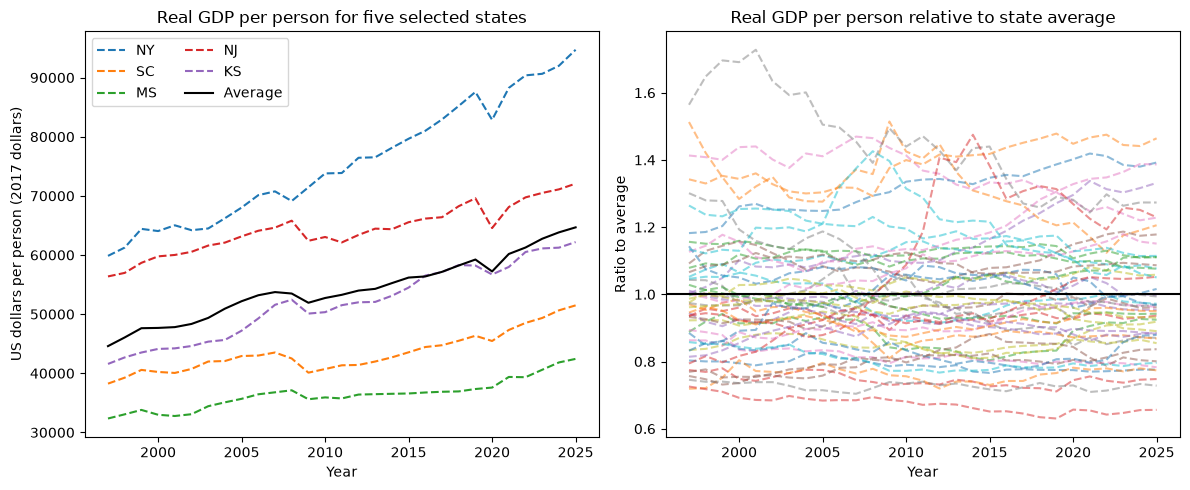

In [10]:
# 1.1.5 Plotting

import matplotlib.pyplot as plt

states_to_plot = ["NY", "SC", "MS", "NJ", "KS"]

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

avg = y.mean(axis=1)
y[states_to_plot].plot(ax=ax1,linestyle="--" )
avg.plot(ax=ax1, color="black", label="Average")

ax1.set_title("Real GDP per person for five selected states")
ax1.set_xlabel("Year")
ax1.set_ylabel("US dollars per person (2017 dollars)")
ax1.legend(ncol=2, fontsize=10)

y_divided=y.div(avg, axis=0)
y_divided.plot(ax=ax2, alpha=0.5,linestyle="--")
ax2.axhline(1, color="black")

ax2.set_title("Real GDP per person relative to state average")
ax2.set_xlabel("Year")
ax2.set_ylabel("Ratio to average")
ax2.get_legend().remove()

fig.tight_layout()

#### 1.2

<Axes: title={'center': 'The standard deviation of log real GDP per person across states'}, xlabel='year', ylabel='std. dev. of $\\log y_{i,t}$ across states'>

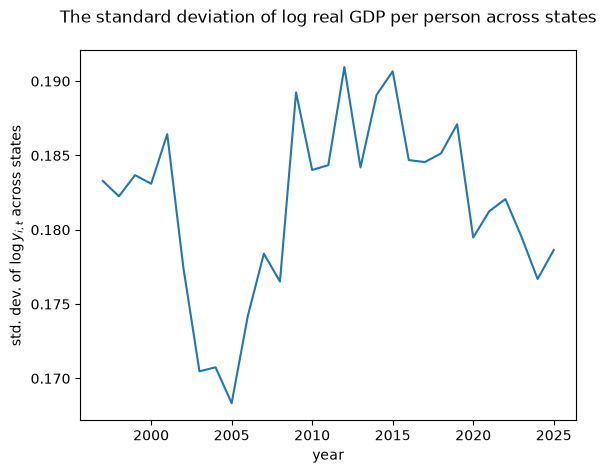

In [11]:
# 1.2.1 Standard deviation

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

std_log = np.log(y).std(axis=1)

ax.set_title("The standard deviation of log real GDP per person across states",pad=20)
ax.set_xlabel("year")
ax.set_ylabel("std. dev. of $\log y_{i,t}$ across states")

std_log.plot()

In [12]:
# 1.2.2

t_first , t_last = std_log.index[0] , std_log.index[-1]
print(f"First value {t_first}: {std_log.iloc[0]:.4f}")
print(f"Last value {t_last}: {std_log.iloc[-1]:.4f}")
print(f"The lowest is {std_log.idxmin()}: {std_log.min():.4f}")
print(f"The highest is {std_log.idxmax()}: {std_log.max():.4f}")

First value 1997: 0.1833
Last value 2025: 0.1786
The lowest is 2005: 0.1683
The highest is 2012: 0.1909


##### 1.2.3

The standard deviation, or variability, of log real GDP per person in the US shows a large dip beginning in 2001 that reached a minimum in 2005 and increased rapidly until about 2009, when the financial crisis was in effect. It began to fall slowly again afterwards, but not as rapidly.

#### 1.3

a = 0.1181
b = -0.0098
corr(g_i,log y_first) = -0.3886


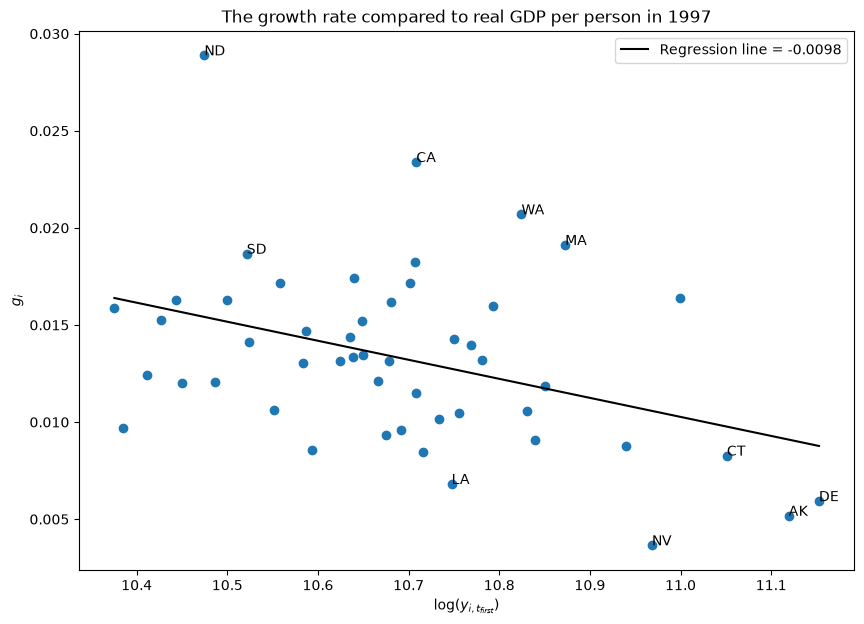

Lambda = 0.0115 per year
h = 60.5


In [13]:
# 1.3.1

# Defining the variables
t_first = y.index.min()
t_last = y.index.max()
log_y = np.log(y)
T = t_last - t_first


# Setting op the function for the anual growth rate between t_first and t_last
g_i = (log_y.loc[t_last] - log_y.loc[t_first]) / T

# setting op the stating point for each state
log_y_start = log_y.loc[t_first]

# Making the scatterplot
fig = plt.figure(figsize = (10,7))
ax=fig.add_subplot(1,1,1)
ax.scatter(log_y_start,g_i)

ax.set_xlabel(r"$\log(y_{i,t_{first}})$")
ax.set_ylabel(r"$g_i$")
ax.set_title("The growth rate compared to real GDP per person in 1997")


# 1.3.2

# Adding the linear regression and reporting a, b and the correlation
b, a = np.polyfit(log_y_start,g_i,1)
x_line = np.linspace(log_y_start.min(),log_y_start.max(),100)
y_line = a + b * x_line
ax.plot(x_line, y_line, color="black", label = f"Regression line = {b:.4f}")
ax.legend()
print(f"a = {a:.4f}")
print(f"b = {b:.4f}")
corr = np.corrcoef(log_y_start, g_i)[0,1]
print(f"corr(g_i,log y_first) = {corr:.4f}")

# 1.3.3 Adding the five states with the highest and lowest g_i

g_i_sorted = g_i.sort_values(ascending=False)
five_highest = g_i_sorted.head(5).index
five_lowest =g_i_sorted.tail(5).index
for state in five_highest:
    ax.text(log_y_start[state],g_i_sorted[state],state,fontsize=10)
for state in five_lowest:
    ax.text(log_y_start[state],g_i_sorted[state],state,fontsize=10)
plt.show()

# 1.3.4
# Reporting lambda and h
_lambda_ = -np.log(1+b*T) / T
h = np.log(2)/_lambda_

print(f"Lambda = {_lambda_:.4f} per year")
print(f"h = {h:.1f}")



##### 1.3.5

There is a high variability from the line of best fit on the scatterplot, though there is a clear overall downwards trend. The five states with a lower GDP per capital in t_first are more poorly represented by the line of best fit; their growth rates g_i were substantially higher than the other values plotted.

#### 1.4

In [46]:
from states import REGION

# 1.4.1 
# Using groupby to include the Regions

y_reset = y.reset_index()
y_long=y_reset.melt(id_vars= "year", var_name= "state", value_name="y")

region = pd.DataFrame(REGION.items(), columns = ["state","region"])
y_long = y_long.merge(region, on="state", how="left", validate="m:1")

print(y_long.head(2))
print(y_long.tail(2))

   year state             y region
0  1997    AL  35807.856017  South
1  1998    AL  36863.947606  South
      year state             y region
1448  2024    WY  67801.616438   West
1449  2025    WY  67924.070026   West


In [47]:
# Finding the average for each region in each given year
region_average = y_long.groupby(["year","region"])["y"].mean()

# Finding the the average across all states
average_across_all_states = y_long.groupby("year")["y"].mean()


# Finding the ratio of each region
region_ratio = (region_average/average_across_all_states)

print(region_ratio)

# Finding number of states per region

count_states = region.groupby("region")["state"].count()
print(count_states)

year  region   
1997  Midwest      0.968332
      Northeast    1.087340
      South        0.951318
      West         1.028682
1998  Midwest      0.968472
                     ...   
2024  West         1.043470
2025  Midwest      1.005527
      Northeast    1.095232
      South        0.905418
      West         1.045378
Name: y, Length: 116, dtype: float64
region
Midwest      12
Northeast     9
South        16
West         13
Name: state, dtype: int64


In [48]:
# Changing the indexing to be able to plot it

region_ratio = region_ratio.reset_index(name="ratio")
region_ratio = region_ratio.pivot_table(index="year",columns="region",values="ratio")

print(region_ratio)

region   Midwest  Northeast     South      West
year                                           
1997    0.968332   1.087340  0.951318  1.028682
1998    0.968472   1.087564  0.957887  1.020313
1999    0.962879   1.091557  0.958916  1.021444
2000    0.976595   1.110827  0.943301  1.014661
2001    0.969318   1.119563  0.948591  1.008820
2002    0.981292   1.113128  0.944005  1.007866
2003    0.988928   1.110676  0.941772  1.005265
2004    0.985121   1.112146  0.942497  1.006868
2005    0.983786   1.103855  0.939935  1.016994
2006    0.975150   1.104261  0.937993  1.027074
2007    0.982829   1.105805  0.923117  1.037225
2008    0.988617   1.110839  0.918395  1.034210
2009    0.984901   1.120930  0.921066  1.027365
2010    0.998890   1.132242  0.918782  1.009433
2011    1.017595   1.120992  0.915451  1.004055
2012    1.035295   1.120903  0.909088  0.995610
2013    1.037836   1.118166  0.909548  0.994593
2014    1.049427   1.110721  0.909002  0.989720
2015    1.042125   1.116397  0.908226  0

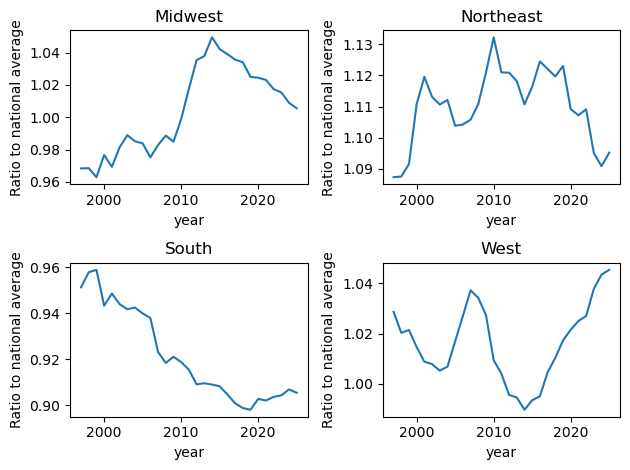

In [49]:
# 1.4.2 Plotting the four regions

fig = plt.figure()

regions = ["Midwest","Northeast","South","West"]
for i, r in enumerate(regions):
    ax = fig.add_subplot(2,2,i+1)
    ax.plot(region_ratio.index,region_ratio[r])

    ax.set_title(r)
    ax.set_xlabel("year")
    ax.set_ylabel("Ratio to national average")

fig.tight_layout()
plt.show()

In [50]:
# 1.4.3


t_first , t_last = region_ratio.index[0] , region_ratio.index[-1]

summary = pd.DataFrame({
    t_first: region_ratio.loc[t_first],
    t_last: region_ratio.loc[t_last],
    "change": region_ratio.loc[t_last] - region_ratio.loc[t_first]
})

print(summary.round(4))

             1997    2025  change
region                           
Midwest    0.9683  1.0055  0.0372
Northeast  1.0873  1.0952  0.0079
South      0.9513  0.9054 -0.0459
West       1.0287  1.0454  0.0167


The south is the region whose ratio between the regional real GDP per person and the national average has changed the most. South´s ratio fell by -0.0459 from 1997 to 2025. The south was already below the national average in 1997, which means that the region has fallen even further behind.

# 2

from types import SimpleNamespace
import numpy as np
import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt

plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'-'})
plt.rcParams.update({'font.size':14})

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

from SolowModel import SolowModelClass

## 2.1

### 2.1.1

In [ ]:
model_sol = SolowModelClass()

print("k_star: ", model_sol.steady_state()[0])
print("y_star: ", model_sol.steady_state()[1])
print("c_star: ", model_sol.steady_state()[2])

k_star_num = model_sol.solve_steady_state() # root_finder

print('k_star_num: ', k_star_num)

#Confirming k_star
assert np.allclose(k_star_num, model_sol.steady_state()[0]), "Cannot confirm k_star"

print("Can confirm k_star")

### 2.1.2

In [ ]:
par = model_sol.par

#variables
T = par.T
s_bar = par.s_bar
alpha = par.alpha
delta = par.delta
k0 = 0.10

#Using the simulate function from SolowModelClass
sim = model_sol.simulate(s=s_bar, k0=k0)


k = sim.k[:T]
t = np.arange(len(k))
s = np.full(len(k), s_bar)

# Calculating the other variables
y = k**alpha
c = (1 - s) * y

# Plotting in three panels
fig, ax = plt.subplots(1, 3, figsize=(15, 6))

ax[0].plot(t, s)
ax[0].set_title(r'Savings rate $s_t$')
ax[0].set_xlabel('t')
ax[0].set_ylabel(r'$s_t$')

ax[1].plot(t, k)
ax[1].set_title(r'Capital $k_t$')
ax[1].set_xlabel('t')
ax[1].set_ylabel(r'$k_t$')

ax[2].plot(t, c)
ax[2].set_title(r'Consumption $c_t$')
ax[2].set_xlabel('t')
ax[2].set_ylabel(r'$c_t$')

plt.tight_layout()
plt.show()

print(f"c_0     = {c[0]:.6f}")
print(f"c_(T-1) = {c[-1]:.6f}")
print(f"k_(T-1) = {k[-1]:.6f}")

### 2.1.3

In [ ]:
# Test 1: An economy starting in k_star must stay there
k_star = model_sol.steady_state()[0]
sim = model_sol.simulate(s=s_bar,k0=k_star)

assert np.allclose(sim.k, k_star), "Test 1 fails"

# Test 2: When s_t=0, capital decays at k_t=(1-delta)*k0
k0_test = 0.10

sim1 = model_sol.simulate(s=0,k0=k0_test)

t_test = np.arange(len(sim1.k))
k_expected = (1 - delta)**t_test * k0_test

assert np.allclose(sim.k, k_expected), "Test 1 fails"

print("All tests passed")

## 2.2

### 2.2.2

In [ ]:
baseline = model_sol.simulate(s=s_bar, k0=k0)

# The combinations
combinations = [
    (0.30, 0.50),
    (0.40, 0.80),
    (0.10, 0.50),
    (0.60, 0.60)
]

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Plotting
ax[0].plot(baseline.s, 'k--', label='Baseline')
ax[1].plot(baseline.k, 'k--', label='Baseline')
ax[2].plot(baseline.c, 'k--', label='Baseline')

# Simulate and plot the four combinations
for s0, phi in combinations:
    s_path = model_sol.s_path(s0, phi)
    sim = model_sol.simulate(s=s_path, k0=k0)

    label = fr'$s_0={s0}, \phi={phi}$'

    ax[0].plot(sim.s, label=label)
    ax[1].plot(sim.k, label=label)
    ax[2].plot(sim.c, label=label)

#The calculations is made with T=100 but I have just shorten the x-axis on the graphs
# so it is easier to see the important parts in the beginning of the simulation.
ax[0].set_xlim(0,25)
ax[1].set_xlim(0,40)
ax[2].set_xlim(0,40)


ax[0].set_title(r'Savings rate $s_t$')
ax[1].set_title(r'Capital $k_t$')
ax[2].set_title(r'Consumption $c_t$')

for a in ax:
    a.set_xlabel('t')
    a.legend()

plt.tight_layout()
plt.show()

### 2.2.3

In [ ]:
# Save the baseline results
baseline = model_sol.simulate(s=s_bar, k0=k0)

print(f"Baseline: k_(T-1) = {baseline.k[T-1]:.6f}")

# Report the final capital stock for each combination
for s0, phi in combinations:
    s_path = model_sol.s_path(s0, phi)
    sim = model_sol.simulate(s=s_path, k0=k0)

    print(
        f"s0 = {s0:.2f}, phi = {phi:.2f}: "
        f"k_(T-1) = {sim.k[T-1]:.6f}"
    )

The final capital stock is the same for all combinations. The capital plot also shows that all curves converge to the same point.

### 2.2.4

For s0 = 0.30, phi = 0.50 (the blue curve) is the closest to the baseline.
\
\
For s0 = 0.40, phi = 0.80 (the orange curve) takes the longest to converge to the baseline.
\
\
For s0 = 0.10, phi = 0.50 (the green curve) is the second closest to the baseline. It is converging to the baseline about the same time as the blue curve. The only difference between this curve and the blue curve is the value of s0. The two curves are relatively close, but the green curve tends to remain below the blue curve and the baseline. In the first graph, the baseline savings rate of 0.25 is above the green curve and below the blue curve in the beginning.
\
\
For s0 = 0.60, phi = 0.60 (the red curve) is the second slowest to converge to the baseline.
\
\
Overall it seems like that phi determines how quickly the savings rate converges to the baseline. s0 determines the distance between the baseline and the curve before converging to the baseline.

## 2.3

### 2.3.2

In [ ]:
# Baseline welfare
W_baseline = model_sol.evaluate(s_bar, 0.0)

results = [{
    "s0": "0.25",
    "phi": "-",
    "W": W_baseline,
    "W - W_baseline": 0.0
}]

# Welfare for the four combinations
for s0, phi in combinations:
    W = model_sol.evaluate(s0, phi)

    results.append({
        "s0": s0,
        "phi": phi,
        "W": W,
        "W - W_baseline": W - W_baseline
    })

# Show the results in a table
welfare_table = pd.DataFrame(results)

display(
    welfare_table.style.format({
        "W": "{:.6f}",
        "W - W_baseline": "{:.6f}"
    })
)

### 2.3.3

People prefer more consumption and smaller saving rate in the beginning of the time period. All the curves show less spending than the baseline at some point in the beginning of the time period. The green curve shows a larger consumption than the baseline just in the beginning and afterwards a smaller consumption for the rest of the time until it moves up to the c_star value.
The orange and red curve have the two smallest consumptions in the beginning but also end up with having the two biggest consumptions just afterwards. These to curves also save more than the baseline in the beginning of the time period. The fast rising in the consumption in the beginning and the bigger saving rate might be a reason for why the welfare for these two curves are smaller than the welfare of the baseline.
\
The blue curve is close to the same starting value as the baseline but becomes bigger after short time. The blue curve is also lying close to the baseline in the graph with capital and in the graph with savings. These to things might be a reason why the blue curve has a larger welfare value than the baseline. The blue curve has a combination with a bit more consumption but also a bit more saving in the beginning compared to the baseline.
\
\
Beta decides how much people prefer to consume instead of saving. The curves cannot show directly which curve that is the best because beta is not included. But from the information above, you can make an educated guess.

## 2.4

### 2.4.1

In [ ]:
N0, Nphi = 40, 40
s0_grid  = np.linspace(0, 0.60, N0)
phi_grid = np.linspace(0, 0.95, Nphi)
    
W_grid = np.empty((N0,Nphi))
for i, s0 in enumerate(s0_grid):
    for j, phi in enumerate(phi_grid):
        W_grid[i,j] = model_sol.evaluate(s0,phi)

idx = np.unravel_index(np.argmax(W_grid), W_grid.shape)
best_s0_grid, best_phi_grid = s0_grid[idx[0]], phi_grid[idx[1]]
W_grid_best = W_grid[idx]

print(f'Best grid point: s0 = {best_s0_grid:.4f}, phi = {best_phi_grid:.4f}, W = {W_grid_best:.4f}')

S0, PHI = np.meshgrid(s0_grid, phi_grid, indexing='ij')
fig, ax = plt.subplots(figsize=(5,4))
cs = ax.contourf(S0, PHI, W_grid, levels=30)
fig.colorbar(cs, label='W')
ax.plot(best_s0_grid, best_phi_grid, 'ro', markersize=6, label='best grid point')
ax.set_xlabel('$s_0$'); ax.set_ylabel('$\\phi$'); ax.legend()
fig.tight_layout()
plt.show()

### 2.4.2

In [ ]:
def neg_W(x):
    s0, phi = x
    return -model_sol.evaluate(s0,phi)

res = optimize.minimize(neg_W, x0=[best_s0_grid, best_phi_grid], bounds=[(0,1),(0,0.999)], method='L-BFGS-B')

s0_opt, phi_opt = res.x
W_opt = -res.fun

print(f'Optimization result: s0 = {s0_opt:.4f}, phi = {phi_opt:.4f}, W = {W_opt:.4f}')
print(f'Grid result: s0 = {best_s0_grid:.4f}, phi = {best_phi_grid:.4f}, W = {W_grid_best:.4f}')
print(f'How much is the optimization better than the grid? {W_opt - W_grid_best:.6f}')

The optimization yields a higher value of $s_0$ and a lower value of $\phi$ than the grid search. The welfare values are almost identical, but the optimization finds the parameter combination with the highest welfare.

### 2.4.3

In [ ]:
baseline = model_sol.simulate(s=s_bar, k0=k0)
baseline_s = baseline.s.copy()
baseline_k = baseline.k.copy()
baseline_c = baseline.c.copy()

s_t = model_sol.s_path(s0_opt, phi_opt)
optimal = model_sol.simulate(s=s_t, k0=k0)

fig, ax = plt.subplots(1, 3, figsize=(18, 9))

# Plot baseline and the best rule
ax[0].plot(baseline_s, 'k--', label='Baseline')
ax[0].plot(optimal.s, label=fr'$s_0={s0_opt:.4f}, \phi={phi_opt:.4f}$')

ax[1].plot(baseline_k, 'k--', label='Baseline')
ax[1].plot(optimal.k, label=fr'$s_0={s0_opt:.4f}, \phi={phi_opt:.4f}$')

ax[2].plot(baseline_c, 'k--', label='Baseline')
ax[2].plot(optimal.c, label=fr'$s_0={s0_opt:.4f}, \phi={phi_opt:.4f}$')

ax[0].set_title(r'Savings rate $s_t$')
ax[1].set_title(r'Capital $k_t$')
ax[2].set_title(r'Consumption $c_t$')

for a in ax:
    a.set_xlabel('t')
    a.legend()

plt.tight_layout()
plt.show()

above_baseline = np.flatnonzero(optimal.c > baseline_c)
first_above = above_baseline[0] if above_baseline.size > 0 else None

print(f'c_0 under the best rule = {optimal.c[0]:.6f}')
if first_above is not None:
    print(f'First period where c_t is above baseline: t = {first_above}')
else:
    print('c_t is never above the baseline during the simulation.')

## 2.5

### 2.5.1

In [ ]:
#Making a new s_path and a new evaluate
def s_path_new(s0,phi,s_inf):
    t = np.arange(par.T)
    return s_inf + (s0 - s_inf)*phi**t

def evaluate_new(s0,phi,s_inf):
    s = s_path_new(s0,phi,s_inf)
    sim = model_sol.simulate(s)
    return model_sol.welfare(sim.c)

#Solving the optimization problem
def neg_W_new(x):
    s0, phi, s_inf = x
    return -evaluate_new(s0,phi,s_inf)

res_new = optimize.minimize(neg_W_new, x0=[s0_opt, phi_opt, 0.25], bounds=[(0,1),(0,0.999),(0,1)], method='L-BFGS-B')

s0_opt_new, phi_opt_new, s_inf_opt_new = res_new.x
W_opt_new = -res_new.fun

print(f'The first optimization result: s0 = {s0_opt:.4f}, phi = {phi_opt:.4f}, W = {W_opt:.4f}')
print(f'The new optimization result: s0 = {s0_opt_new:.4f}, phi = {phi_opt_new:.4f}, s_inf = {s_inf_opt_new:.4f},W = {W_opt_new:.4f}')
print(f'How much is the new optimization better than the frist optimization? {W_opt_new - W_opt:.6f}')

### 2.5.2

In [ ]:
# Compare k_(T-1) of the new time-varying rule with k_star from question 1
t=np.arange(par.T)

s_t_new = s_inf_opt_new + (s0_opt_new - s_inf_opt_new) * phi_opt_new**t
sim_new = model_sol.simulate(s=s_t_new, k0=k0)
k_new = sim_new.k[:T].copy()

k_star = model_sol.steady_state()[0]

print(f"k_(T-1) = {k_new[-1]:.6f}")
print(f"k_star = {k_star:.6f}")

k_star_new = model_sol.steady_state(s_inf_opt_new)[0]
print(f"k_star_new = {k_star_new:.6f}")

The baseline steady-state capital k_star is 0.760726, whereas the capital stock in the final simulation period, k_(T-1), is 0.540026. The two values differ because they are based on two different s_values, but the meaning of the two k_values are the same. k_(T-1) is also the k value in steady state after the saving rule has been updated like k_star was the steady state value before the update.

## 2.6

### 2.6.1 and 2.6.2

In [ ]:
#Making a new s_path and a new evaluate
def s_path_newest(s0,phi,s_inf, A):
    t = np.arange(par.T)
    return s_inf + (s0 - s_inf+A*t)*phi**t

def evaluate_newest(s0,phi,s_inf, A):
    s = s_path_newest(s0,phi,s_inf, A)
    sim = model_sol.simulate(s)
    return model_sol.welfare(sim.c)

#Solving the optimization problem
def neg_W_newest(x):
    s0, phi, s_inf, A = x
    return -evaluate_newest(s0,phi,s_inf, A)

res_newest = optimize.minimize(neg_W_newest, x0=[s0_opt_new, phi_opt_new, s_inf_opt_new, 0.0], bounds=[(0,1),(0,0.999),(0,1), (0.0001,0.5)], method='L-BFGS-B')

s0_opt_newest, phi_opt_newest, s_inf_opt_newest, A_opt_newest = res_newest.x
W_opt_newest = -res_newest.fun
    
print(f'The new optimization result: s0 = {s0_opt_newest:.4f}, phi = {phi_opt_newest:.4f}, s_inf = {s_inf_opt_newest:.4f}, A = {A_opt_newest:.4f}, W = {W_opt_newest:.4f}')

### 2.6.3

In [ ]:
results_W = [{
    "saving rule": "old (grid)",
    "s0": best_s0_grid,
    "phi": best_phi_grid,
    "W": W_baseline
}]
results_W.append({
    "saving rule": "old (optimization)",
    "s0": s0_opt,
    "phi": phi_opt,
    "W": W_baseline
})
results_W.append({
    "saving rule": "updated (question 5)",
    "s0": s0_opt_new,
    "phi": phi_opt_new,
    "W": W_opt_new
})
results_W.append({
    "saving rule": "my version (question 6)",
    "s0": s0_opt_newest,
    "phi": phi_opt_newest,
    "W": W_opt_newest
})

# Show the results in a table
welfare_table_new = pd.DataFrame(results_W)

display(welfare_table_new.style.format({"W": "{:.6f}"}))

In [ ]:
print(f'How much is the new optimization better than the frist optimization? {W_opt_newest - W_opt_new:.8f}')

My version is very closed to the updated one from number 5 but the welfare is a bit below the welfare level in question 5.

## 3 A portfolio with a risky and safe asset

##### 3.1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'axes.grid':True,
                     'grid.color':'black',
                     'grid.alpha':'0.25',
                     'font.size': '12',
                     'grid.linestyle':'--'})

from PortfolioModel import PortfolioModelClass

# 3.1.1 draw returns, method from given PortfolioModelClass
model = PortfolioModelClass()
R = model.draw_returns() #computes Rt
print(f'R.shape = {R.shape}') #reports shape of R to verify, instead of printing the entire array

# 3.2.2 compare to the calibration
print(f'mean of log(R)  = {np.log(R).mean():.4f}  (mu = {model.par.mu})')
print(f'std of log(R)   = {np.log(R).std():.4f}  (sigma = {model.par.sigma})')
print(f'mean of R       = {R.mean():.4f}  (exp(mu+0.5*sigma^2) = {np.exp(model.par.mu+0.5*model.par.sigma**2):.4f})')

# 3.1.3 hist and plot
fig, axes = plt.subplots(1,2, figsize=(12,4.5))

axes[0].hist(R.flatten(), bins=100, color='blue')
axes[0].set_title(' $R_t$')
axes[0].set_xlabel('$R_t$')
axes[0].set_ylabel('frequency')
axes[0].set_xlim(0, 2.25)

Rf = np.exp(model.par.r)
risky_path = np.cumprod(R[:20,:], axis=1)
safe_path = Rf**np.arange(1, model.par.T+1)
for i in range(20):
    axes[1].plot(risky_path[i,:], color='blue', alpha=0.4, linewidth=1)
axes[1].plot(safe_path, color='black', linewidth=2, label='safe asset')
axes[1].set_yscale('log')
axes[1].set_title('Value of 1 invested: risky (blue) vs. safe (black)')
axes[1].set_xlabel('period')
axes[1].legend()

fig.tight_layout()

#### 3.2

In [ ]:
# 3.2.1
def run_analysis(): 
    
    model0 = PortfolioModelClass(Delta=0.0, tau=0.0)
    model1 = PortfolioModelClass(Delta=1.0, tau=0.0)
    returns = model0.draw_returns()
    model0.simulate(R=returns)
    model1.simulate(R=returns)
    return model0, model1

# 3.2.2 summary table
def print_summaries(models): 
    for name, model in models:
        summary = model.summary()
        print(name)
        print(f"  Average trades:             {summary.avg_trades:.4f}")
        print(f"  Average distance to target: {summary.avg_dist:.4f}")
        print(f"  Mean of terminal wealth:    {summary.mean_WT:.4f}")
        print(f"  Median of terminal wealth:  {summary.median_WT:.4f}")
        print(f"  10th percentile of wealth:  {summary.p10_WT:.4f}")
        print(f"  Expected utility:           {summary.EU:.4f}")

#3.2.3 plots
def make_plots(model0, model1): #plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    ax0 = axes[0]
    ax0.hist(model0.sim.W[:, -1], bins=100, range=(0, 20), density=True,
             alpha=0.5, label=r"Trade Every Period ($\Delta = 0.0$)",
             color="blue")
    ax0.hist(model1.sim.W[:, -1], bins=100, range=(0, 20), density=True,
             alpha=0.5, label=r"Never Trade ($\Delta = 1.0$)",
             color="orange")
    ax0.set_xlabel("Terminal wealth $W_T$")
    ax0.set_ylabel("Probability density")
    ax0.set_title("Terminal wealth $W_T$")
    ax0.legend(fontsize=14)

    ax1 = axes[1]
    time_grid = np.arange(model0.par.T + 1)
    for model, label, color in [
        (model0, r"$\Delta = 0.0$", "blue"),
        (model1, r"$\Delta = 1.0$", "orange"),
    ]:
        mean_theta = model.sim.theta.mean(axis=0)
        p10_theta = np.percentile(model.sim.theta, 10, axis=0)
        p90_theta = np.percentile(model.sim.theta, 90, axis=0)
        ax1.plot(time_grid, mean_theta, color=color, linewidth=2, label=label)
        ax1.fill_between(time_grid, p10_theta, p90_theta, color=color, alpha=0.15)


    ax1.set_xlabel("Period $t$")
    ax1.set_ylabel("$\\theta_t$")
    ax1.set_title("$\\theta_t$ over time")
    ax1.legend(fontsize=14)
    fig.tight_layout()



models = run_analysis()

print_summaries([
    ("Rule 1: Delta = 0.0 (Trade every period)", models[0]),
    ("Rule 2: Delta = 1.0 (Never trade)", models[1]),
])

make_plots(*models)
plt.show()


##### 3.2.4

With delta=1 the risky asset has a positive expected return, the average theta_t climbs from 0.50 to about 0.78 by period 40, and its 10th–90th percentile band widens. Delta=1, or never-trading, gives a higher mean terminal wealth W_t (8.98 vs 5.04 for delta=0) from more risk exposure but a lower expected utility (−0.0767 vs −0.0678 for delta=0). Trading every period maximizes expected utility despite returning lower average terminal wealth.

### 3.3

In [ ]:
import pandas as pd

# 3.3.1 returns for listed bandwidths with tau=0.01; draw_returns from portfoliomodelclass
base = PortfolioModelClass(tau=0.01)
R = base.draw_returns()
deltas = [0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1]

rows = []
for d in deltas:
    m = PortfolioModelClass(Delta=d, tau=0.01)
    m.simulate(R=R)
    s = m.summary()
    rows.append({'Delta':d, 'avg_trades':s.avg_trades, 'avg_dist':s.avg_dist,
                 'mean_WT':s.mean_WT, 'median_WT':s.median_WT, 'p10_WT':s.p10_WT, 'EU':s.EU})

table = pd.DataFrame(rows).set_index('Delta').round(4)
display(table)

# 3.3.2 plots
fig, axes = plt.subplots(1,2, figsize=(12,4.5)) 

ax1 = axes[0]
ax1.plot(table.index, table['avg_trades'], 'o-', color='blue')
ax1.set_xlabel('$\Delta$'); ax1.set_ylabel('avg. number of trades', color='blue')
ax2 = ax1.twinx()
ax2.plot(table.index, table['avg_dist'], 's-', color='red')
ax2.set_ylabel('avg. distance to target', color='red')
ax1.set_title('Trading activity vs. band width')
ax1.tick_params(axis='y', labelsize=8) #tick labels resize
ax2.tick_params(axis='y', labelsize=8)

best_delta = table['EU'].idxmax() #define max Delta
axes[1].plot(table.index, table['EU'], 'o-', color='green')
axes[1].set_xlabel('$\Delta$'); axes[1].set_ylabel('$E[u(W_T)]$')
axes[1].set_title('Expected utility vs. band width')
axes[1].tick_params(axis='y', labelsize=8) 

fig.tight_layout()

# 3.3.3 comparison 
print(f"best Delta = {best_delta}, EU = {table.loc[best_delta,'EU']:.4f}") #locate values corresponding to max Delta
print(f"improvement over Delta=0: {table.loc[best_delta,'EU'] - table.loc[0,'EU']:+.4f}")
print(f"improvement over Delta=1: {table.loc[best_delta,'EU'] - table.loc[1,'EU']:+.4f}")

##### 3.3.3
The highest expected utility is given by delta=0.075, beating delta=0 by 0.0006 and delta=1 by 0.0074.

##### 3.3.4
As delta increases from 0 to 0.075, average trades falls a lot (from 39 to 8.8) with only a small change in distance-to-target (from 0.039 to 0.048) or in expected utility. 
Ranking by mean W_T instead of expected utility sees mean wealth increases significantly with delta=1 over delta=0 as shown in the table. This results in favoring the rule delta=1 (never trade), despite that rule decreasing expected utility.